https://tensorflow.classcat.com/2021/03/07/mediapipe-0-8-colab-face-mesh/

In [1]:
!pip install mediapipe

     |████████████████████████████████| 32.8 MB 52 kB/s 


In [2]:
import cv2
from google.colab.patches import cv2_imshow

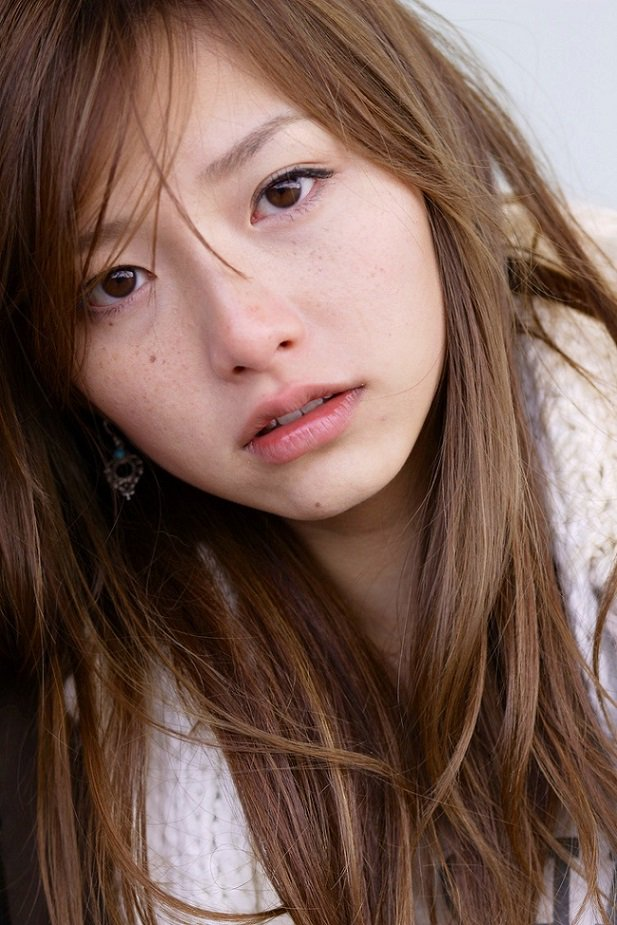

In [3]:
image = cv2.imread("/content/drive/MyDrive/kaggle/mediapipe/kanzakikanae.jpg")
cv2_imshow(image)

In [4]:
import mediapipe as mp
mp_face_mesh = mp.solutions.face_mesh

In [5]:
mp_drawing = mp.solutions.drawing_utils 
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)

landmark {
  x: 0.45846810936927795
  y: 0.43378373980522156
  z: -0.06774912029504776
}
landmark {
  x: 0.40925702452659607
  y: 0.38570520281791687
  z: -0.14431992173194885
}
landmark {
  x: 0.42714640498161316
  y: 0.3969692885875702
  z: -0.06862757354974747
}
landmark {
  x: 0.3443987965583801
  y: 0.3352525532245636
  z: -0.11349482834339142
}
landmark {
  x: 0.39414432644844055
  y: 0.36972665786743164
  z: -0.15646404027938843
}
landmark {
  x: 0.3761981129646301
  y: 0.34628236293792725
  z: -0.14890533685684204
}
landmark {
  x: 0.33380648493766785
  y: 0.2853829264640808
  z: -0.08529271185398102
}
landmark {
  x: 0.15830105543136597
  y: 0.3304212987422943
  z: 0.04670676216483116
}
landmark {
  x: 0.2946808934211731
  y: 0.2368854284286499
  z: -0.07410246133804321
}
landmark {
  x: 0.27390071749687195
  y: 0.21378743648529053
  z: -0.0852554589509964
}
landmark {
  x: 0.20196793973445892
  y: 0.12784315645694733
  z: -0.07445793598890305
}
landmark {
  x: 0.4657447338104

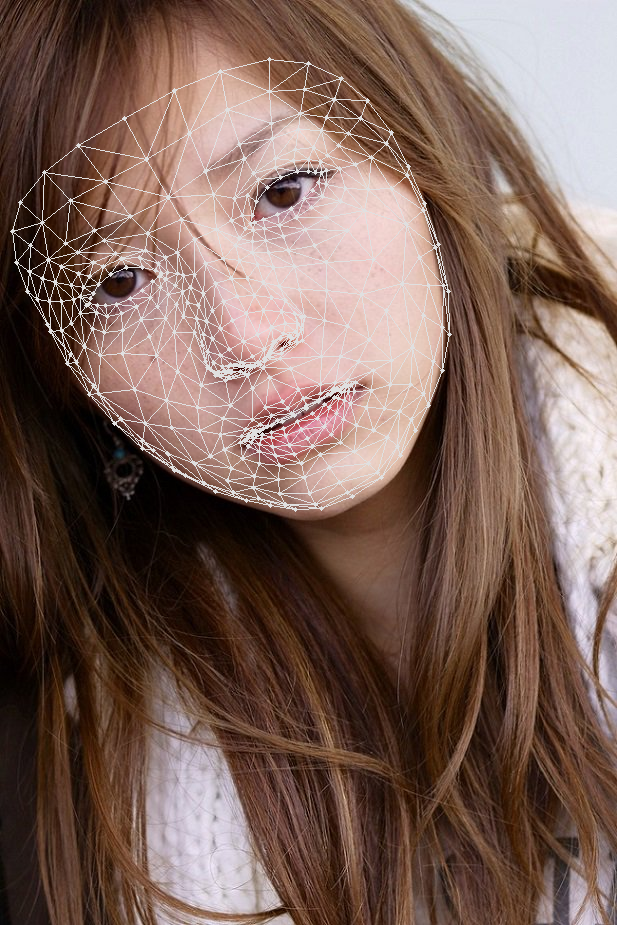

In [6]:
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=2,
    min_detection_confidence=0.5) as face_mesh:
    # Convert the BGR image to RGB and process it with MediaPipe Face Mesh.
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Draw face landmarks of each face.
    annotated_image = image.copy()
    for face_landmarks in results.multi_face_landmarks:
        print(face_landmarks)
        mp_drawing.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=drawing_spec,
            connection_drawing_spec=drawing_spec)
    cv2_imshow(annotated_image)

In [7]:
import csv

In [8]:
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=2,
    min_detection_confidence=0.5) as face_mesh:
    # Convert the BGR image to RGB and process it with MediaPipe Face Mesh.
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Draw face landmarks of each face.
    annotated_image = image.copy()

    labels=['x','y','z']
    with open('/content/drive/MyDrive/kaggle/mediapipe/randmark.csv', 'a', newline='') as file:
        landmark_point=[]
        writer=csv.writer(f)
        for landmarks in results.multi_face_landmarks:
            for index, landmark in enumerate(landmarks.landmark):
                landmark_x = min(int(landmark.x * image_width), image_width - 1)
                landmark_y = min(int(landmark.y * image_height), image_height - 1)
                landmark_ = landmark_x,landmark_y
                landmark_point.append(landmark_x)
                landmark_point.append(landmark_y)
            writer.writerow(np.array(landmark_point))

    #print(results.multi_face_landmarks)
    for face_landmarks in results.multi_face_landmarks:
        #print(face_landmarks)
        mp_drawing.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=drawing_spec,
            connection_drawing_spec=drawing_spec)
    cv2_imshow(annotated_image)

NameError: ignored